In [1]:
# Machine Learing (Clustering/Regressione)


In [1]:
# Importo le Librerie necessarie
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

In [2]:
# definiscoco il data frame
percorso_file = "../../01_Data/Clean_Data/istat_incidenti_pulito_2019_2023.csv"
df_finale = pd.read_csv(percorso_file, dtype={'Codice_Comune': str})

In [3]:
# Preparo i dati, filtrando i comuni >5k abitanti, aggregando i 5 anni.
df_ml = df_finale[df_finale['Popolazione'] >= 5000].copy()

df_cluster = df_ml.groupby('Nome_Comune', as_index=False).agg(
    Popolazione=('Popolazione', 'mean'),
    Totale_Incidenti=('Totale_Incidenti', 'sum'),
    Morti=('Morti', 'sum')
)

# Devo calcolare le metriche aziendali chiave.
df_cluster['Tasso_Rischio_10k'] = (df_cluster['Totale_Incidenti'] / df_cluster['Popolazione']) * 10000
df_cluster['Letalita_Perc'] = (df_cluster['Morti'] / df_cluster['Totale_Incidenti']) * 100
df_cluster['Letalita_Perc'] = df_cluster['Letalita_Perc'].fillna(0)

# Scalatura.
X = df_cluster[['Tasso_Rischio_10k', 'Letalita_Perc']]

# Applico la libreria StandardScaler.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# KMEANS
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)

#
df_cluster['Cluster_Rischio'] = kmeans.fit_predict(X_scaled)

Exception in thread Thread-27 (_readerthread):
Traceback (most recent call last):
  File "c:\Users\giuli\miniconda3\envs\boolean\Lib\threading.py", line 1075, in _bootstrap_inner
    self.run()
  File "c:\Users\giuli\miniconda3\envs\boolean\Lib\site-packages\ipykernel\ipkernel.py", line 772, in run_closure
    _threading_Thread_run(self)
  File "c:\Users\giuli\miniconda3\envs\boolean\Lib\threading.py", line 1012, in run
    self._target(*self._args, **self._kwargs)
  File "c:\Users\giuli\miniconda3\envs\boolean\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "<frozen codecs>", line 322, in decode
UnicodeDecodeError: 'utf-8' codec can't decode byte 0x8a in position 123: invalid start byte
c:\Users\giuli\miniconda3\envs\boolean\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by settin

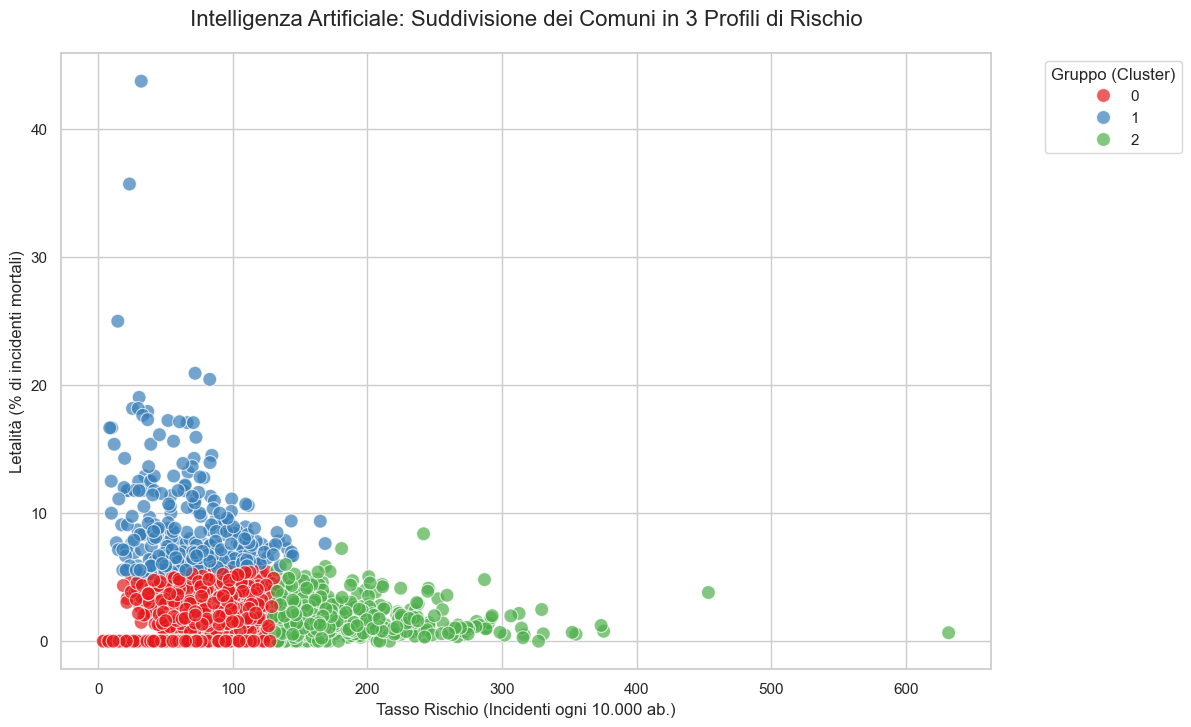

--- COMPOSIZIONE DEI CLUSTER ---
Cluster_Rischio
0    1464
2     601
1     305
Name: count, dtype: int64


In [4]:
# Imposto il grafico di visualizzazione dei Cluster.
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

# Scatter Plot
sns.scatterplot(
    data=df_cluster,
    x='Tasso_Rischio_10k',
    y='Letalita_Perc',
    hue='Cluster_Rischio',
    palette='Set1',
    s=100,
    alpha=0.7
)

# Titolo ed etichette.
plt.title('Intelligenza Artificiale: Suddivisione dei Comuni in 3 Profili di Rischio', fontsize=16, pad=20)
plt.xlabel('Tasso Rischio (Incidenti ogni 10.000 ab.)', fontsize=12)
plt.ylabel('Letalità (% di incidenti mortali)', fontsize=12)

# Legenda
plt.legend(title='Gruppo (Cluster)', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

# Stampo i Risultati.
print("--- COMPOSIZIONE DEI CLUSTER ---")
print(df_cluster['Cluster_Rischio'].value_counts())

In [ ]:
# Analisi dei risultati:
# Pallini Rossi: rappresentano i comuni con basso rischio di incidenti e 0 morti, ovvero la stragrande
# maggioranza dei comuni italiani (gruppo 0: 1464 comuni). Qui a mio parere non vi è nessuna 
# priorità di investimento.

# Pallini blu: rappresentano i comuni con basso rischio di incidenti ma quei pochi sono letali, perchè
# i pallini sono più vicini all'asse y che rappresenta la letalità.
# Potrebbero essere principalmente strade ad alta velocità, poco illuminate, strade dissestate ecc..
# In questo secondo gruppo di comuni 305 comuni proporrei investimenti come Guardrail, Autovelox, 
# Asfalto drenante, illuminazione necessaria ecc...

# Pallini verdi: rappresentano i comuni con più alto rischio di incidenti e allo stesso tempo, 
# un basso rischio di morte. Quindi posso dedurre che questi 601 comuni sono località con un 
# traffico a bassa velocità, dovrò comunque fare altre indagini a riguardo con codice.
# Qui si potrebbe proporre investimenti come Semafori, Rotonde, Dossi rallentatori ecc...
# 
# Devo comunque scrivere altro codice per poter estrarre valore da questo grafico. 

In [6]:
# Voglio verificare i peggiori dei nomi dei comuni italiani che appartengono sia al gruppo
# Blu sia qiello Verde.

# Isolo il Cluster 1 (Blu - Alta Letalità)
cluster_blu_letale = df_cluster[df_cluster['Cluster_Rischio'] == 1].sort_values(by='Letalita_Perc', ascending=False)
print("CLUSTER 1 (I PALLINI BLU): I 5 Comuni con gli incidenti più MORTALI (Target per Guardrail/Autovelox)")
display(cluster_blu_letale[['Nome_Comune', 'Popolazione', 'Totale_Incidenti', 'Morti', 'Letalita_Perc']].head(5))

# Isolo il Cluster 2 (Verde - Caos e Tamponamenti)
cluster_verde_caos = df_cluster[df_cluster['Cluster_Rischio'] == 2].sort_values(by='Tasso_Rischio_10k', ascending=False)
print("CLUSTER 2 (I PALLINI VERDI): I 5 Comuni con più INCIDENTI in proporzione, ma bassa letalità (Target per Semafori/Rotonde)")
display(cluster_verde_caos[['Nome_Comune', 'Popolazione', 'Totale_Incidenti', 'Morti', 'Tasso_Rischio_10k']].head(5))


CLUSTER 1 (I PALLINI BLU): I 5 Comuni con gli incidenti più MORTALI (Target per Guardrail/Autovelox)


,Nome_Comune,Popolazione,Totale_Incidenti,Morti,Letalita_Perc
287,Bucchianico,5002.0,16,7,43.750000
1208,Mattinata,6016.0,14,5,35.714286
1845,San Giuseppe Jato,8208.0,12,3,25.000000
2237,Valle Aurina/Ahrntal,5971.0,43,9,20.930233
767,Custonaci,5307.0,44,9,20.454545


CLUSTER 2 (I PALLINI VERDI): I 5 Comuni con più INCIDENTI in proporzione, ma bassa letalità (Target per Semafori/Rotonde)


,Nome_Comune,Popolazione,Totale_Incidenti,Morti,Tasso_Rischio_10k
875,Forte dei Marmi,7217.0,456,3,631.841485
194,Bentivoglio,5801.0,263,10,453.370109
1083,Lignano Sabbiadoro,6870.0,258,2,375.545852
1932,Santa Margherita Ligure,8724.0,326,4,373.681797
195,Bergamo,119993.0,4260,23,355.020710


In [ ]:
# Non mi piace comunque il risultato del gruppo 1 perchè escono comuni con poca popolazione,
# quindi non so quanto senso abbia fare investimenti in comuni cosi piccoli visto che comunque immagino
# che l'azienda di prevenzione dei rischi dovrà farsi pagare dal comune, quindi è più facile che sia
# un comune ricco e popolato ad essere il target migliore. 

# Dal Gruppo 2 rimangono ancora in testa come nelle precedenti analisi di barchart, Forte dei Marmi e Bergamo.
# Questi 2 comuni sono entrambi dei buoni target per diversi motivi tra di loro.
# Forte dei Marmi è una località tursitica e Bergamo rimane comunque una città molto congesionata essendo
# comunque una grossa provincia Industriale.